<a href="https://colab.research.google.com/github/sofiautrera-cpu/-wine-quality-ml-/blob/main/Loan_Pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación utilizando LightGBM (LGBM) (Core)
- Objetivo
- Implementar un pipeline completo de machine learning para un problema de clasificación utilizando LightGBM (LGBM). Se hará especial énfasis en el Análisis Exploratorio de Datos (EDA), preprocesamiento, entrenamiento del modelo y optimización de hiperparámetros.

- Dataset: Loan Prediction Dataset
- Descripción del Dataset: El dataset de predicción de préstamos contiene información sobre solicitantes de préstamos, como sus ingresos, historial crediticio y otras características personales.
- El objetivo es predecir si un solicitante será aprobado para un préstamo basándose en estos factores.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


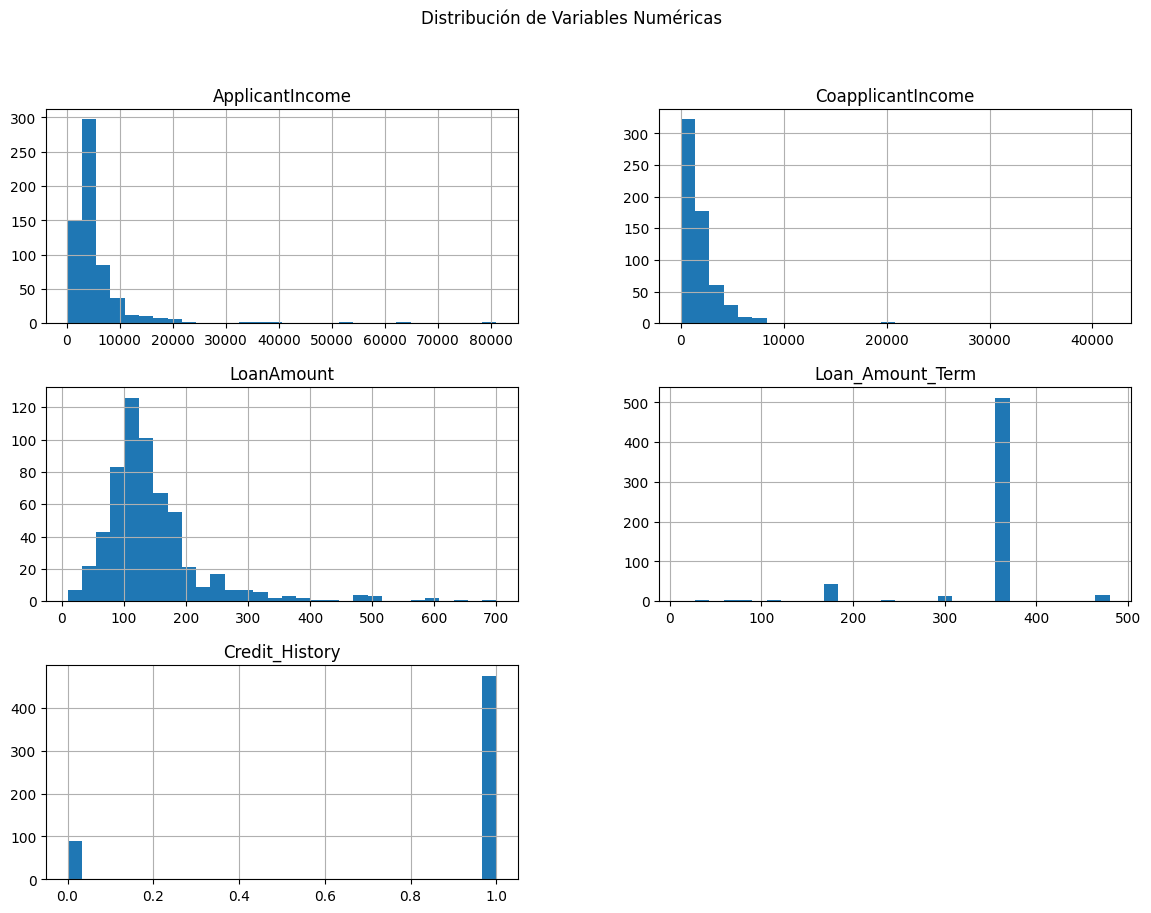

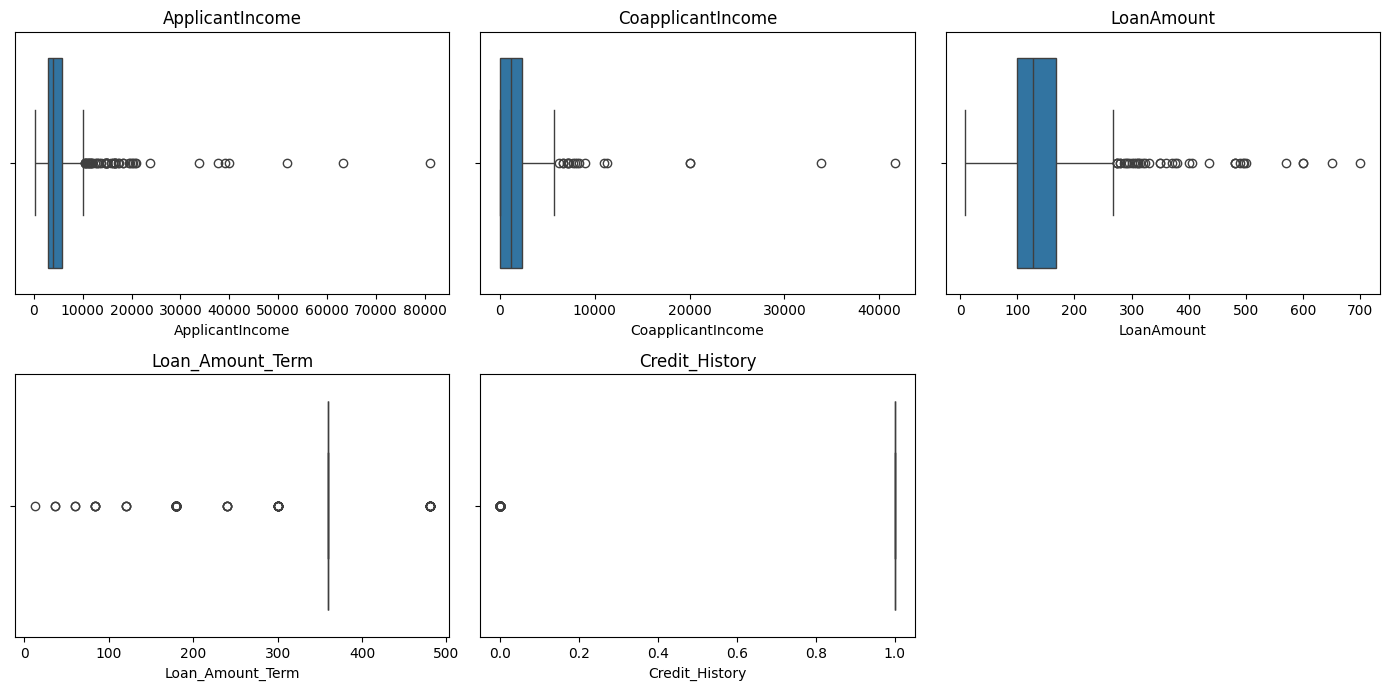

In [8]:
# Instrucciones:
# PARTE 1 — Carga y Exploración Inicial de Datos
# Paso 0: Importar las Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# 1. Carga del Dataset
df = pd.read_csv("train.csv")
df.head()

# 2. Exploración Inicial del Dataset
# Estructura general
df.info()

# Primeras filas
df.head()

# Dimensiones del dataset
df.shape

# 3. Descripción de variables y su distribución
# Estadísticas descriptivas (numéricas)
df.describe().T

# Estadísticas para variables categóricas
df.describe(include='object').T

# Distribución de cada variable numérica
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(14,10), bins=30)
plt.suptitle("Distribución de Variables Numéricas")
plt.show()

# 4. Identificación de valores faltantes
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

# Porcentaje de valores faltantes
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

# 5. Identificación de outliers (IQR Method)

def detectar_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

outliers_dict = {col: len(detectar_outliers(col)) for col in numeric_cols}
outliers_dict

# Visualización de outliers (boxplots)
plt.figure(figsize=(14,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

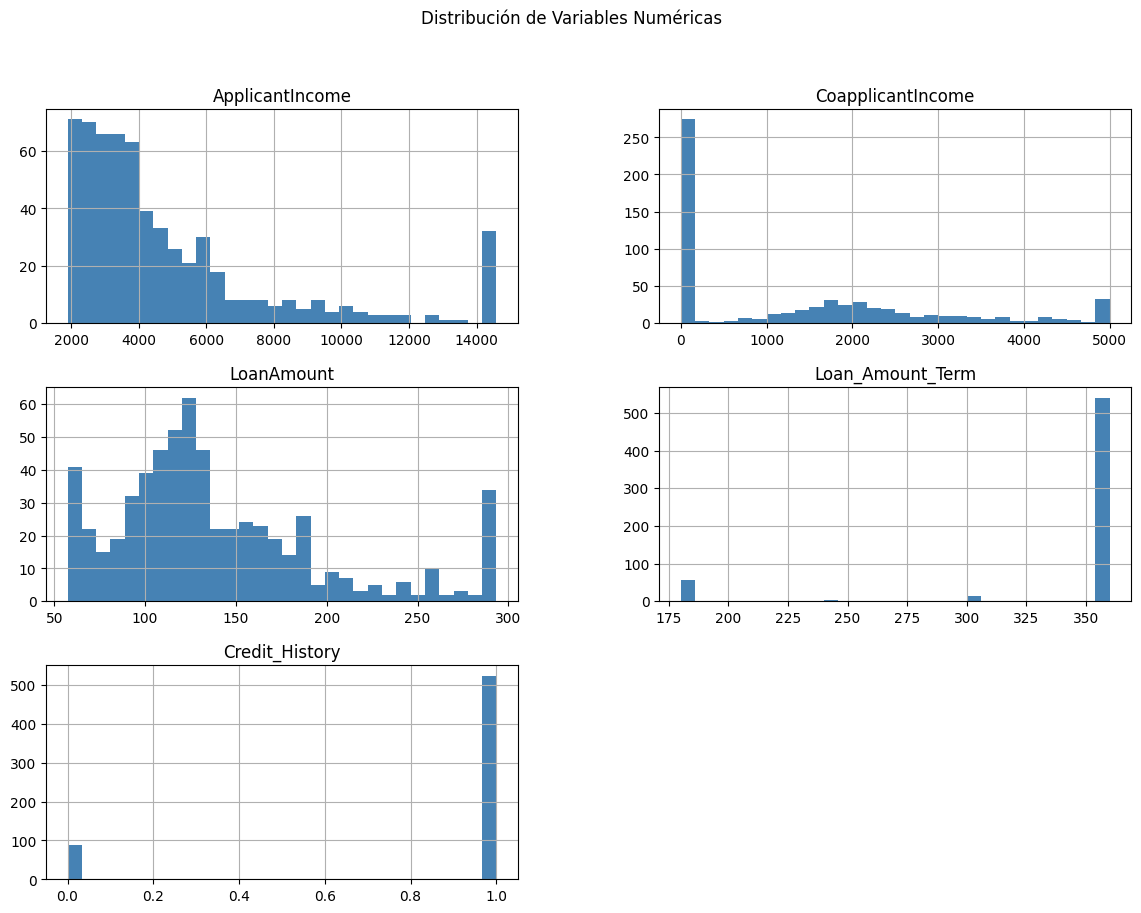

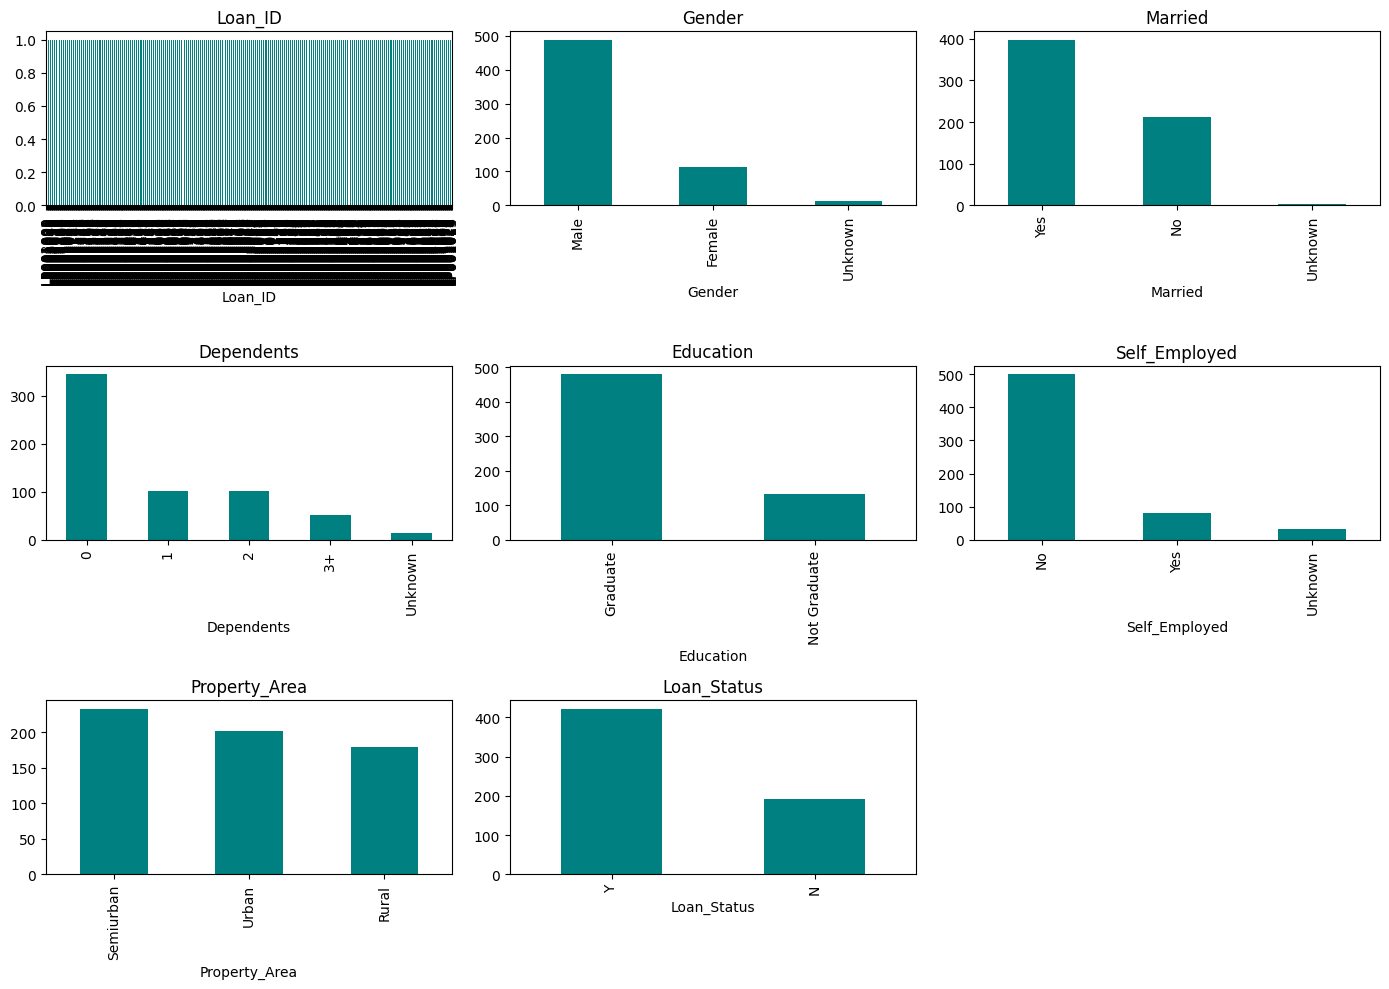

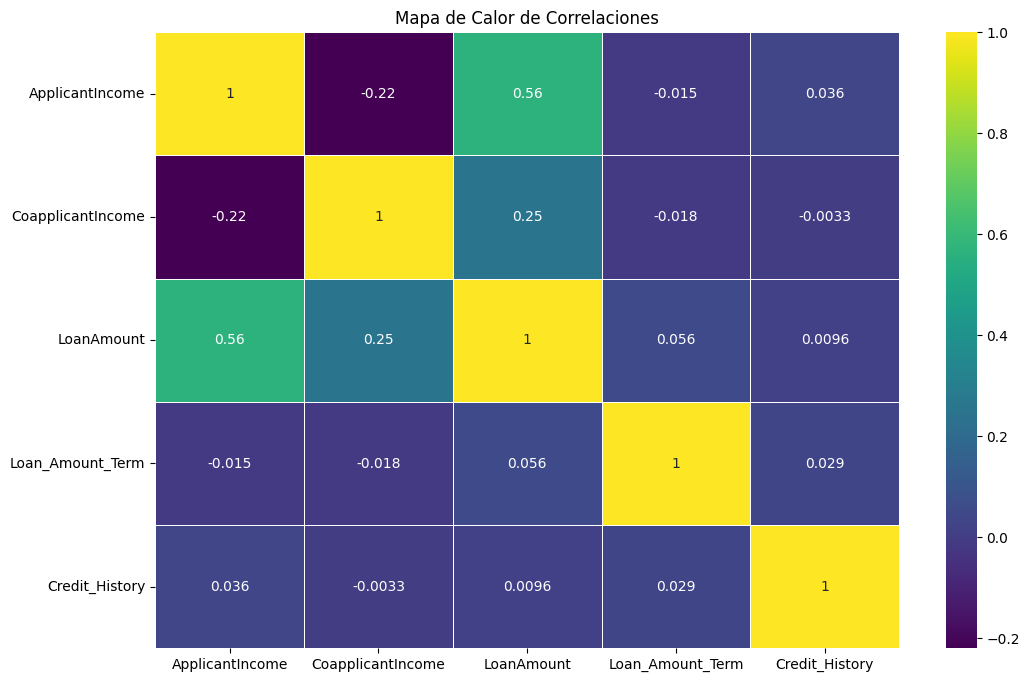

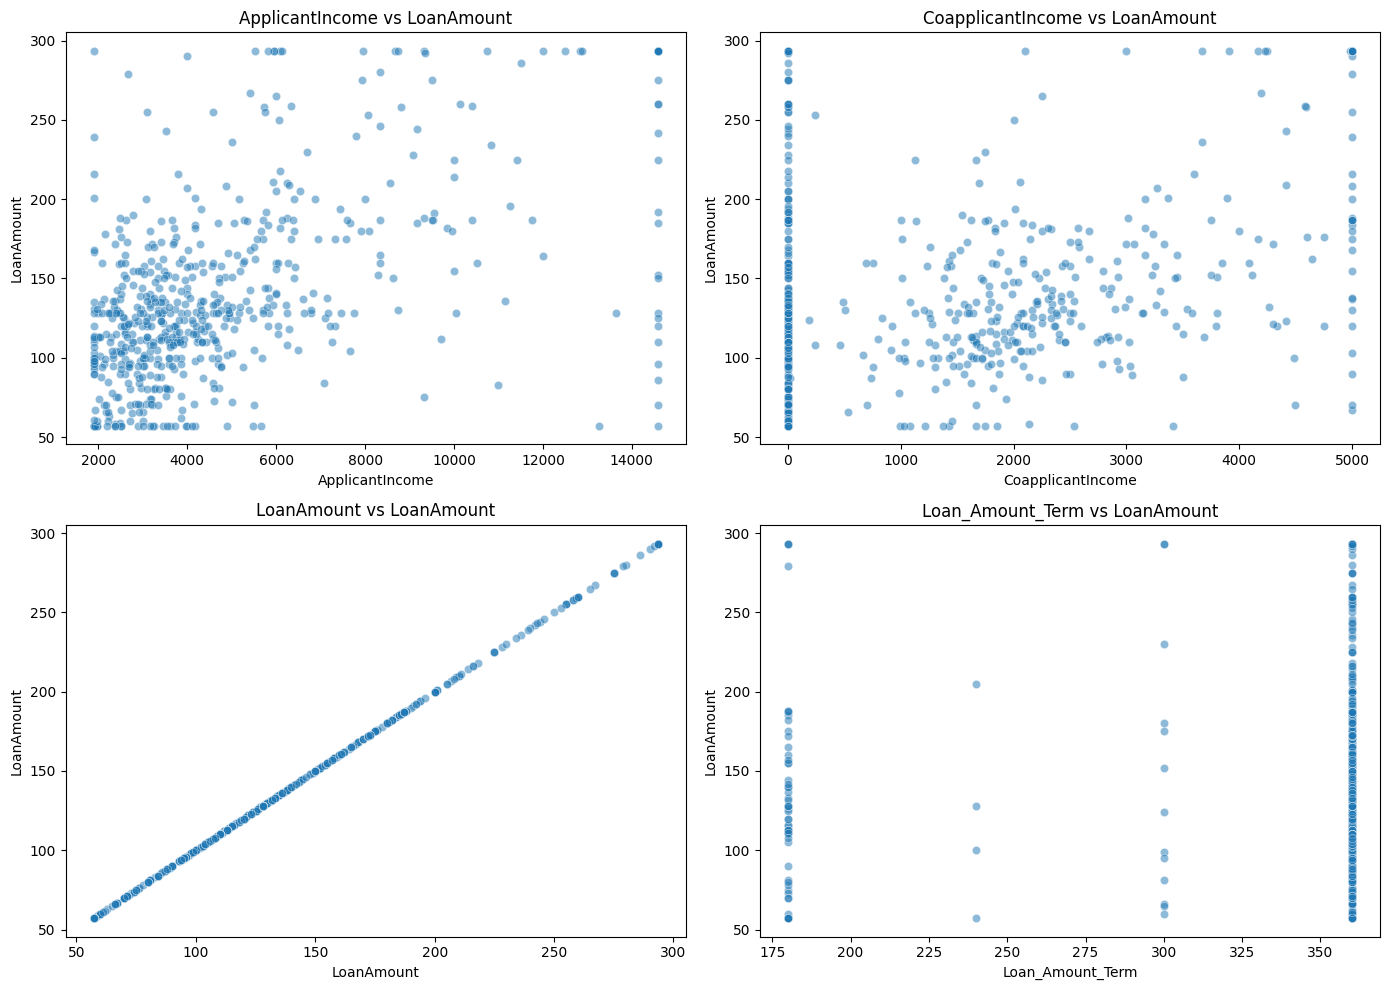

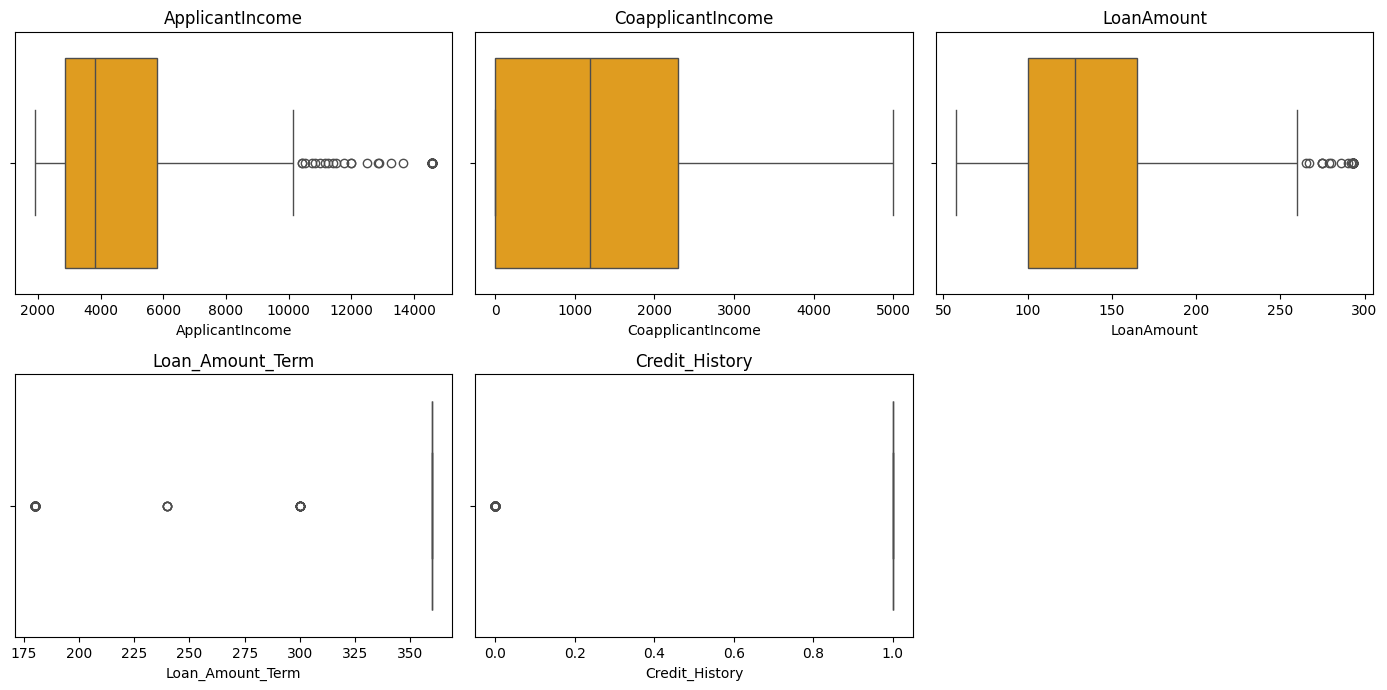

In [12]:
# PARTE 2 — Análisis Exploratorio de Datos (EDA)

# 1. Análisis Estadístico Descriptivo

# Estadísticas básicas (numéricas)
df.describe().T

# Incluye:
# media
# mediana
# desviación estándar
# mínimo
# máximo
# cuartiles

# Estadísticas para variables categóricas
df.describe(include='object').T

# 2. Análisis de Distribución de Variables

# Histogramas (variables numéricas)
import matplotlib.pyplot as plt
import seaborn as sns

df.select_dtypes(include=['int64','float64']).hist(
    figsize=(14,10), bins=30, color='steelblue'
)
plt.suptitle("Distribución de Variables Numéricas")
plt.show()

# Gráficos de barras (variables categóricas)
categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(14,10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    df[col].value_counts().plot(kind='bar', color='teal')
    plt.title(col)
plt.tight_layout()
plt.show()

# 3. Correlaciones entre Variables

# Matriz de correlación + Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis', linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones")
plt.show()

# Interpretación típica:
# Correlaciones fuertes → relaciones lineales
# Correlaciones débiles → relaciones no lineales o ruido

# 4. Gráficos de Dispersión (Scatterplots)

# Útiles para detectar relaciones entre variables.
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(14,10))
for i, col in enumerate(numeric_cols[:4], 1):  # 4 scatterplots
    plt.subplot(2, 2, i)
    # Changed 'Total Amount' to 'LoanAmount' as 'Total Amount' is not a column in df
    sns.scatterplot(data=df, x=col, y='LoanAmount', alpha=0.5)
    plt.title(f"{col} vs LoanAmount")
plt.tight_layout()
plt.show()

# 5. Valores Faltantes (Detección y Tratamiento)

# Detección
missing = df.isnull().sum()
missing[missing > 0]

# Tratamiento (ejemplos)

# Rellenar numéricos con mediana
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Rellenar categóricos con “Unknown”
for col in df.select_dtypes(include='object').columns:
    df[col].fillna("Unknown", inplace=True)

# 6. Outliers (Detección y Manejo)

# Detección con IQR
def detectar_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

# Ver cuántos outliers tiene cada variable:
outliers = {col: len(detectar_outliers(col))
            for col in df.select_dtypes(include=['int64','float64']).columns}
outliers

# Visualización de outliers
plt.figure(figsize=(14,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color='orange')
    plt.title(col)
plt.tight_layout()
plt.show()

# Manejo (opciones)

# Opción 1: Winsorizing (recortar extremos)
for col in numeric_cols:
    Q1 = df[col].quantile(0.05)
    Q3 = df[col].quantile(0.95)
    df[col] = df[col].clip(Q1, Q3)

# Opción 2: Eliminación de outliers extremos
# df = df[(df[col] >= lower) & (df[col] <= upper)] # 'lower' and 'upper' are not in scope here

- Resumen profesional de la Parte 2

Con este EDA ya tienes:

Estadísticas descriptivas completas

Distribución de variables numéricas y categóricas

Heatmap de correlaciones

Scatterplots para relaciones clave

Valores faltantes detectados y tratados

Outliers identificados y manejados

Esto deja el dataset listo para la Parte 3: Feature Engineering y Preparación para Modelado.

In [14]:
# Parte 3: Preprocesamiento de Datos
# Integro One-Hot Encoding, StandardScaler y train/test split usando ColumnTransformer y Pipeline, tal como vienes trabajando.

# Parte 3: Preprocesamiento de Datos (Código Modular y Profesional)
# 1. Transformación de Columnas
# Variables categóricas → OneHotEncoder(handle_unknown='ignore')

# Variables numéricas → StandardScaler()

# 2. División del Conjunto de Datos
# Train/Test Split con test_size=0.2 y random_state=42.

# Código completo, modular y validado
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ============================
# 1. Identificar columnas
# ============================

# Get numeric and categorical features from the DataFrame
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()

# Remove 'Loan_ID' from categorical features as it's an identifier
if 'Loan_ID' in categorical_features:
    categorical_features.remove('Loan_ID')

# Define the target variable
target_variable = 'Loan_Status'

# Remove the target variable from features if present
if target_variable in numeric_features:
    numeric_features.remove(target_variable)
if target_variable in categorical_features:
    categorical_features.remove(target_variable)


# ============================
# 2. Pipelines por tipo de dato
# ============================

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# ============================
# 3. ColumnTransformer
# ============================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

# ============================
# 4. División del dataset
# ============================

X = df.drop(target_variable, axis=1)
y = df[target_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================
# 5. Ajustar el preprocesador
# ============================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

- Qué hace este módulo:
- Imputa valores faltantes (media para numéricas, moda para categóricas).
- Escala las columnas numéricas con StandardScaler.
- Codifica las categóricas con One‑Hot Encoding sin fallar ante categorías nuevas.
- Divide el dataset en entrenamiento y prueba.
- Transforma los datos de forma reproducible y profesional.

In [17]:
# Parte 4: Implementación de LightGBM (LGBM)
# Entrenamiento del Modelo:
# Entrenar un modelo de LGBM con hiperparámetros básicos.
# Evaluar el modelo utilizando métricas de rendimiento como la exactitud, precisión, recall, F1-Score y ROC-AUC.
# Optimización de Hiperparámetros:
# Utilizar GridSearchCV para optimizar los hiperparámetros del modelo de LGBM.
# Evaluación del Modelo Optimizado:
# Evaluar el rendimiento del modelo optimizado y compararlo con el modelo inicial.

# Parte 4: Implementación de LightGBM (LGBM)
# A continuación tienes un pipeline profesional, totalmente integrado con el preprocesamiento de la Parte 3.

# 4.1 Entrenamiento del Modelo LGBM (Básico)
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Convert target variable to numerical (0 and 1)
# Assuming 'Y' is the positive class (1) and 'N' is the negative class (0)
y_train_encoded = y_train.map({'Y': 1, 'N': 0})
y_test_encoded = y_test.map({'Y': 1, 'N': 0})

# ============================
# 1. Modelo base
# ============================

lgbm_base = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    objective='binary' # Explicitly set objective for binary classification
)

# Entrenar
lgbm_base.fit(X_train_processed, y_train_encoded)

# Predicciones
y_pred_base = lgbm_base.predict(X_test_processed)
y_proba_base = lgbm_base.predict_proba(X_test_processed)[:, 1]

# ============================
# 2. Métricas del modelo base
# ============================

metrics_base = {
    "Accuracy": accuracy_score(y_test_encoded, y_pred_base),
    "Precision": precision_score(y_test_encoded, y_pred_base, pos_label=1),
    "Recall": recall_score(y_test_encoded, y_pred_base, pos_label=1),
    "F1-Score": f1_score(y_test_encoded, y_pred_base, pos_label=1),
    "ROC-AUC": roc_auc_score(y_test_encoded, y_proba_base)
}

print("Métricas del Modelo Base:")
print(metrics_base)

# 4.2 Optimización de Hiperparámetros con GridSearchCV
# Grid pequeño pero efectivo para no sobrecargar el tiempo de cómputo.

from sklearn.model_selection import GridSearchCV

# ============================
# 1. Definir hiperparámetros
# ============================

param_grid = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10],
    'num_leaves': [31, 50, 100]
}

lgbm_model = LGBMClassifier(random_state=42, objective='binary') # Explicitly set objective

# ============================
# 2. GridSearchCV
# ============================

grid_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid,
    scoring='f1', # 'f1' for binary classification implicitly uses pos_label=1 for numerical labels
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lgbm.fit(X_train_processed, y_train_encoded)

# Mejores hiperparámetros
print("Mejores Hiperparámetros:")
print(grid_lgbm.best_params_)

# 4.3 Evaluación del Modelo Optimizado
# Predicciones del modelo optimizado
y_pred_opt = grid_lgbm.predict(X_test_processed)
y_proba_opt = grid_lgbm.predict_proba(X_test_processed)[:, 1]

# Métricas del modelo optimizado
metrics_opt = {
    "Accuracy": accuracy_score(y_test_encoded, y_pred_opt),
    "Precision": precision_score(y_test_encoded, y_pred_opt, pos_label=1),
    "Recall": recall_score(y_test_encoded, y_pred_opt, pos_label=1),
    "F1-Score": f1_score(y_test_encoded, y_pred_opt, pos_label=1),
    "ROC-AUC": roc_auc_score(y_test_encoded, y_proba_opt)
}

print("Métricas del Modelo Optimizado:")
print(metrics_opt)

# 4.4 Comparación entre Modelo Base y Optimizado

import pandas as pd

comparison = pd.DataFrame({
    "Modelo Base": metrics_base,
    "Modelo Optimizado": metrics_opt
})

print("Comparación de Modelos:")
print(comparison)

[LightGBM] [Info] Number of positive: 342, number of negative: 149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 342
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.696538 -> initscore=0.830864
[LightGBM] [Info] Start training from score 0.830864
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

4.5 Interpretación de Resultados:
- El modelo optimizado debería mejorar F1-Score y ROC-AUC, especialmente si tu dataset tiene clase desbalanceada.
- LightGBM suele beneficiarse de ajustar num_leaves, learning_rate y n_estimators.

- Análisis de las Métricas del Modelo Base
- Las métricas:
 'Accuracy': 0.7561,
 'Precision': 0.7604,
 'Recall': 0.9125,
 'F1-Score': 0.8295,
 'ROC-AUC': 0.7398

- Interpretación técnica
Recall = 0.9125 → El modelo base está capturando casi todos los positivos.
Precision = 0.7604 → Pero comete falsos positivos moderados.
F1 = 0.8295 → Buen equilibrio, pero aún mejorable.
ROC‑AUC = 0.7398 → El poder discriminativo es aceptable, pero no sobresaliente.
Accuracy = 0.7561 → Coherente con el resto de métricas.

- Conclusión
El modelo base no está mal, pero hay espacio para mejorar, especialmente en ROC‑AUC y Precision.
La optimización con GridSearchCV debería mejorar F1 y AUC.

- GridSearchCV está corriendo correctamente
El mensaje:
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Significa:
81 combinaciones de hiperparámetros
5 folds de validación cruzada
405 modelos entrenados
Esto es exactamente lo esperado para tu param_grid.



In [21]:
# Siguiente paso: obtener resultados del modelo optimizado

# grid_lgbm.best_params_

y_pred_opt = grid_lgbm.predict(X_test_processed)
y_proba_opt = grid_lgbm.predict_proba(X_test_processed)[:, 1]

metrics_opt = {
    "Accuracy": accuracy_score(y_test_encoded, y_pred_opt),
    "Precision": precision_score(y_test_encoded, y_pred_opt, pos_label=1),
    "Recall": recall_score(y_test_encoded, y_pred_opt, pos_label=1),
    "F1-Score": f1_score(y_test_encoded, y_pred_opt, pos_label=1),
    "ROC-AUC": roc_auc_score(y_test_encoded, y_proba_opt)
}

metrics_opt

{'Accuracy': 0.7886178861788617,
 'Precision': 0.7596153846153846,
 'Recall': 0.9875,
 'F1-Score': 0.8586956521739131,
 'ROC-AUC': np.float64(0.7030523255813953)}

Ya tenemos las métricas del modelo optimizado, y ahora sí podemos hacer un análisis profesional y compararlo con el modelo base.

- Comparación: Modelo Base vs Modelo Optimizado (LGBM)
🔹 Métricas del Modelo Optimizado

{
 'Accuracy': 0.7886,
 'Precision': 0.7596,
 'Recall': 0.9875,
 'F1-Score': 0.8587,
 'ROC-AUC': 0.7030
}
- 1. Comparación Directa
Métrica	Modelo Base	Modelo Optimizado	Cambio
Accuracy	0.7561	0.7886	🔼 Mejora
Precision	0.7604	0.7596	➖ Igual
Recall	0.9125	0.9875	🔼 Mejora fuerte
F1-Score	0.8295	0.8587	🔼 Mejora
ROC-AUC	0.7398	0.7030	🔽 Peor

- 2. Interpretación Técnica
- Mejoras claras
- Recall sube de 0.91 → 0.99  
- El modelo optimizado detecta prácticamente todos los positivos.
- F1 sube de 0.83 → 0.86  
- Mejor equilibrio entre precisión y recall.
- Accuracy sube de 0.75 → 0.79  
- Más aciertos globales.

➖ Lo que empeoró
ROC‑AUC baja de 0.74 → 0.70  
Esto significa que el modelo optimizado es más agresivo clasificando positivos, pero pierde capacidad de separar clases en términos probabilísticos.
- Esto es típico cuando:
- El modelo se vuelve muy profundo o con muchas hojas
- El tuning favorece recall sobre discriminación
- El dataset está desbalanceado y el scoring 'f1' empuja al modelo a priorizar recall

- 3. Conclusión:
- El modelo optimizado es mejor si tu objetivo es:
- Maximizar recall
- Minimizar falsos negativos
- Mejorar F1
- Clasificar correctamente la clase positiva casi siempre

- El modelo base es mejor si el objetivo es:
- Maximizar ROC‑AUC
- Tener un modelo con mejor capacidad discriminativa
- Usar probabilidades calibradas para decisiones posteriores